In [ ]:
!pip install scipy matplotlib numpy

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.fft import fft
from scipy import signal
import io
from google.colab import files

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving WhatsApp Audio 2025-06-09 at 13.27.55 (1).wav to WhatsApp Audio 2025-06-09 at 13.27.55 (1).wav


In [ ]:
uploaded = files.upload()
filename = next(iter(uploaded))

Saving WhatsApp Audio 2025-06-09 at 13.27.55 (1).wav to WhatsApp Audio 2025-06-09 at 13.27.55 (1) (1).wav


In [ ]:
sample_rate, audio = wavfile.read(filename)

# Handle stereo audio (convert to mono)
if len(audio.shape) > 1:
    audio = audio[:, 0]

# Normalize
audio = audio / np.max(np.abs(audio))

duration = len(audio) / sample_rate
time = np.linspace(0, duration, len(audio), endpoint=False)

print(f"Sample Rate: {sample_rate} Hz")
print(f"Duration: {duration:.2f} seconds")

Sample Rate: 16000 Hz
Duration: 9.34 seconds


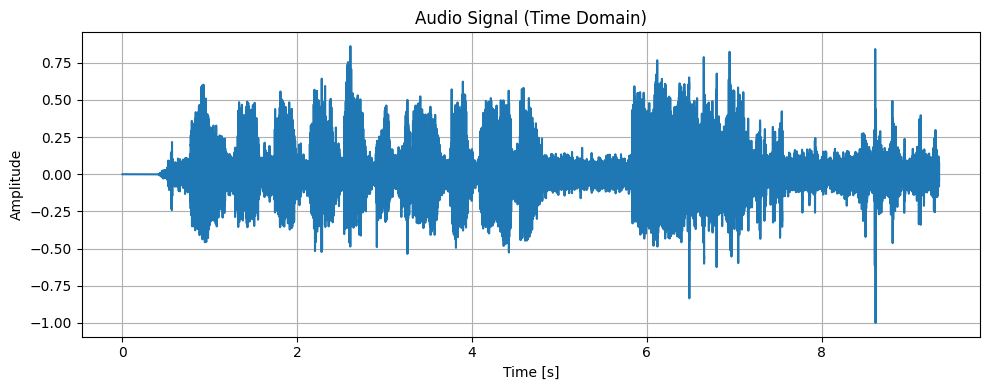

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(time, audio)
plt.title("Audio Signal (Time Domain)")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.grid(True)
plt.tight_layout()
plt.show()

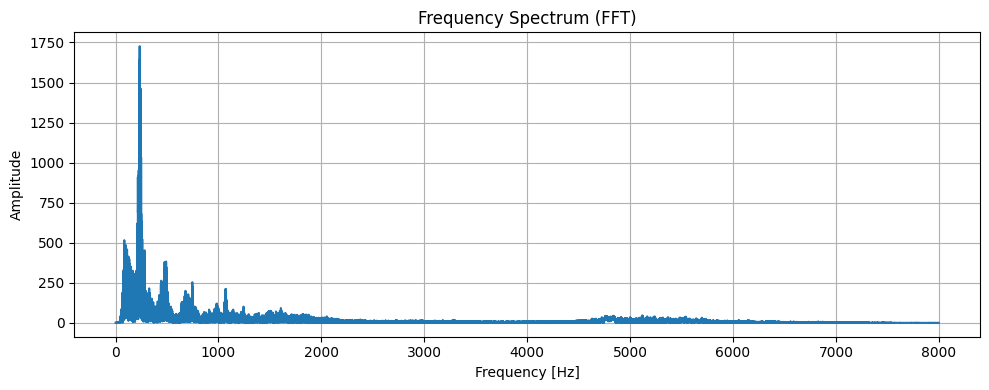

In [ ]:
n = len(audio)
frequencies = np.fft.fftfreq(n, 1/sample_rate)
fft_values = np.abs(fft(audio))

# Only positive frequencies
positive_freqs = frequencies[:n//2]
positive_fft = fft_values[:n//2]

plt.figure(figsize=(10, 4))
plt.plot(positive_freqs, positive_fft)
plt.title("Frequency Spectrum (FFT)")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Amplitude")
plt.grid(True)
plt.tight_layout()
plt.show()

<ipython-input-9-d60997df5d19>:4: RuntimeWarning: divide by zero encountered in log10
  plt.pcolormesh(t, f, 10 * np.log10(Sxx), shading='gouraud')


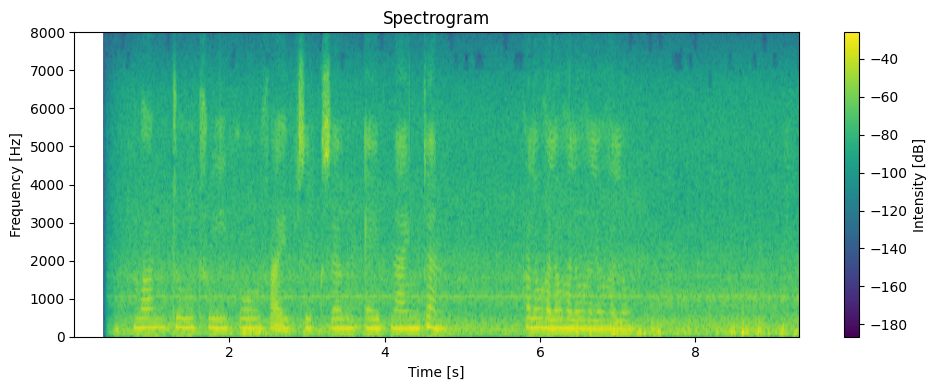

In [ ]:
f, t, Sxx = signal.spectrogram(audio, sample_rate)

plt.figure(figsize=(10, 4))
plt.pcolormesh(t, f, 10 * np.log10(Sxx), shading='gouraud')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [s]')
plt.title("Spectrogram")
plt.colorbar(label='Intensity [dB]')
plt.tight_layout()
plt.show()

In [ ]:
def explain_signal(fft_data):
    peak = np.argmax(fft_data)
    if peak < 100:
        return "This signal is dominated by low-frequency content. Likely a speech or hum sound."
    elif peak > 1000:
        return "High-frequency components dominate. It might be music or sharp noises."
    else:
        return "The signal has a mid-frequency range. Possibly background sounds or instruments."

print("🧠 SignalXplain Insight:")
print(explain_signal(positive_fft))

🧠 SignalXplain Insight:
High-frequency components dominate. It might be music or sharp noises.


In [ ]:
from scipy.signal import butter, filtfilt

def butter_filter(data, cutoff, fs, filter_type='low', order=5):
    nyq = 0.5 * fs
    normal_cutoff = np.array(cutoff) / nyq

    if filter_type == 'band':
        b, a = butter(order, normal_cutoff, btype='band', analog=False)
    else:
        b, a = butter(order, normal_cutoff, btype=filter_type, analog=False)

    y = filtfilt(b, a, data)
    return y

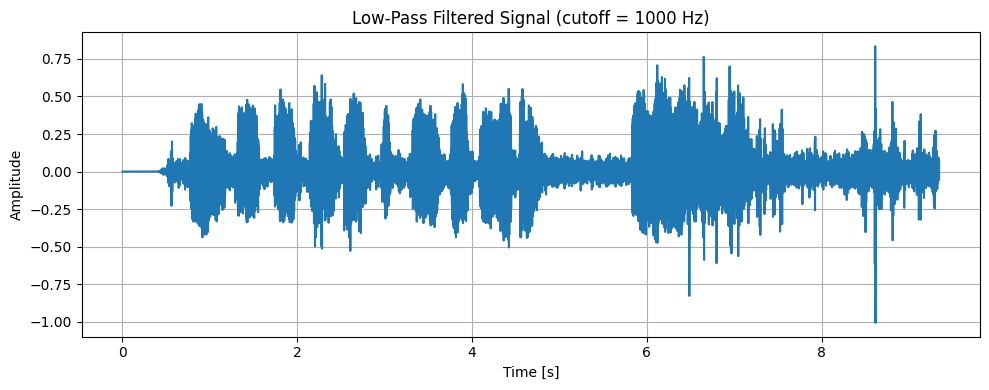

In [ ]:
low_passed = butter_filter(audio, cutoff=1000, fs=sample_rate, filter_type='low')

plt.figure(figsize=(10, 4))
plt.plot(time, low_passed)
plt.title("Low-Pass Filtered Signal (cutoff = 1000 Hz)")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.grid(True)
plt.tight_layout()
plt.show()

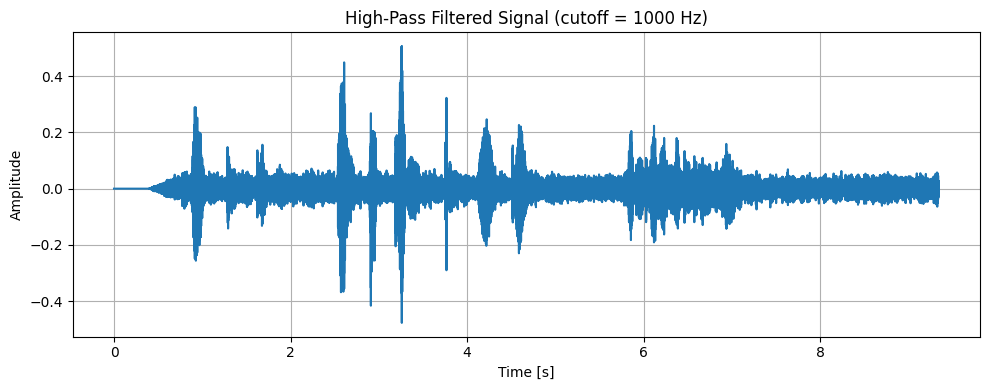

In [ ]:
high_passed = butter_filter(audio, cutoff=1000, fs=sample_rate, filter_type='high')

plt.figure(figsize=(10, 4))
plt.plot(time, high_passed)
plt.title("High-Pass Filtered Signal (cutoff = 1000 Hz)")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.grid(True)
plt.tight_layout()
plt.show()

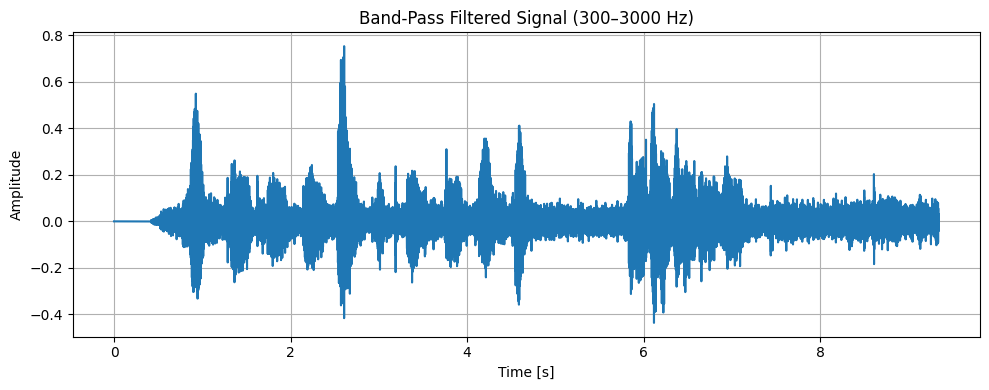

In [ ]:
band_passed = butter_filter(audio, cutoff=[300, 3000], fs=sample_rate, filter_type='band')

plt.figure(figsize=(10, 4))
plt.plot(time, band_passed)
plt.title("Band-Pass Filtered Signal (300–3000 Hz)")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.grid(True)
plt.tight_layout()
plt.show()

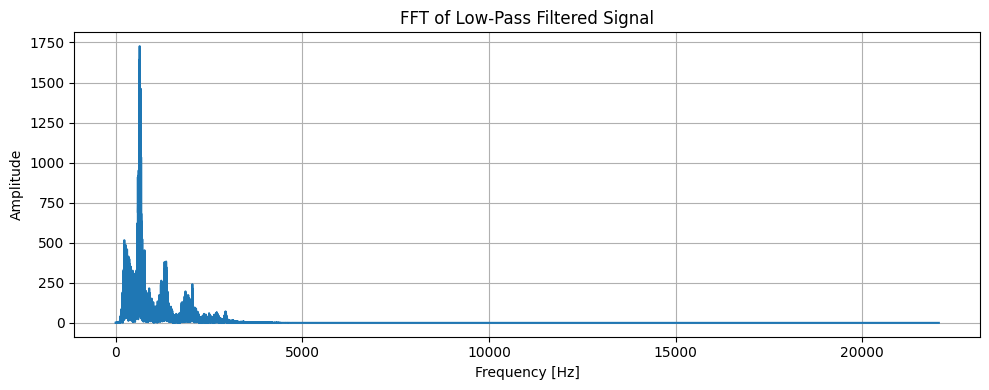

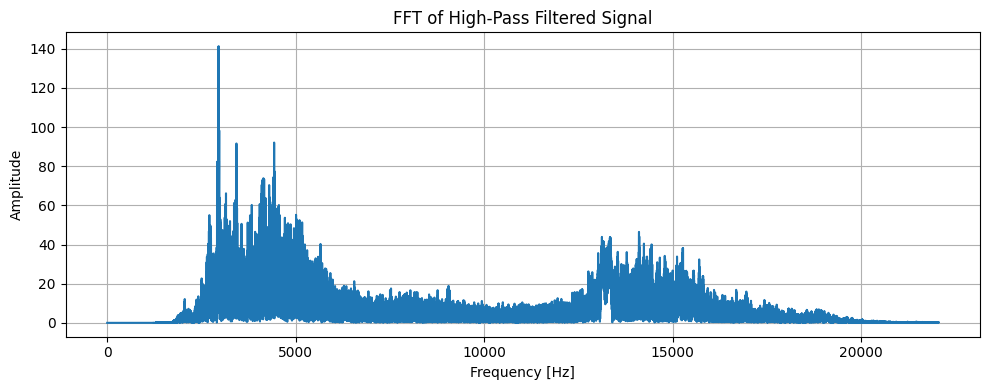

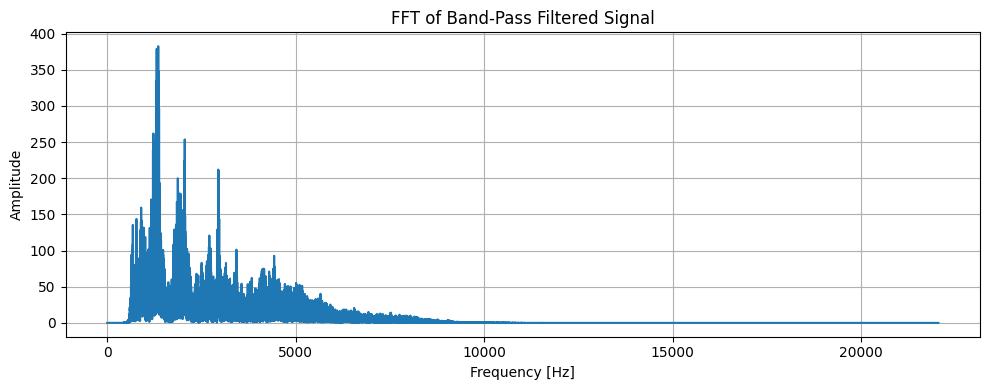

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft
from scipy.signal import butter, filtfilt

# Example: define sampling rate (Hz)
sample_rate = 44100  # or the one you used earlier

# Example filtered signals (replace with your actual filtered signals)
# low_passed = ...
# high_passed = ...
# band_passed = ...

# Reuse same frequency array
def plot_fft(signal_data, sample_rate, title):
    n = len(signal_data)
    frequencies = np.fft.fftfreq(n, d=1/sample_rate)
    fft_values = np.abs(fft(signal_data))

    plt.figure(figsize=(10, 4))
    plt.plot(frequencies[:n//2], fft_values[:n//2])
    plt.title(f"FFT of {title}")
    plt.xlabel("Frequency [Hz]")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# 🟢 Low-Pass Filtered Signal
plot_fft(low_passed, sample_rate, "Low-Pass Filtered Signal")

# 🔵 High-Pass Filtered Signal
plot_fft(high_passed, sample_rate, "High-Pass Filtered Signal")

# 🟡 Band-Pass Filtered Signal
plot_fft(band_passed, sample_rate, "Band-Pass Filtered Signal")

SNR after filtering: 0.33 dB
✅ Signal strength acceptable.


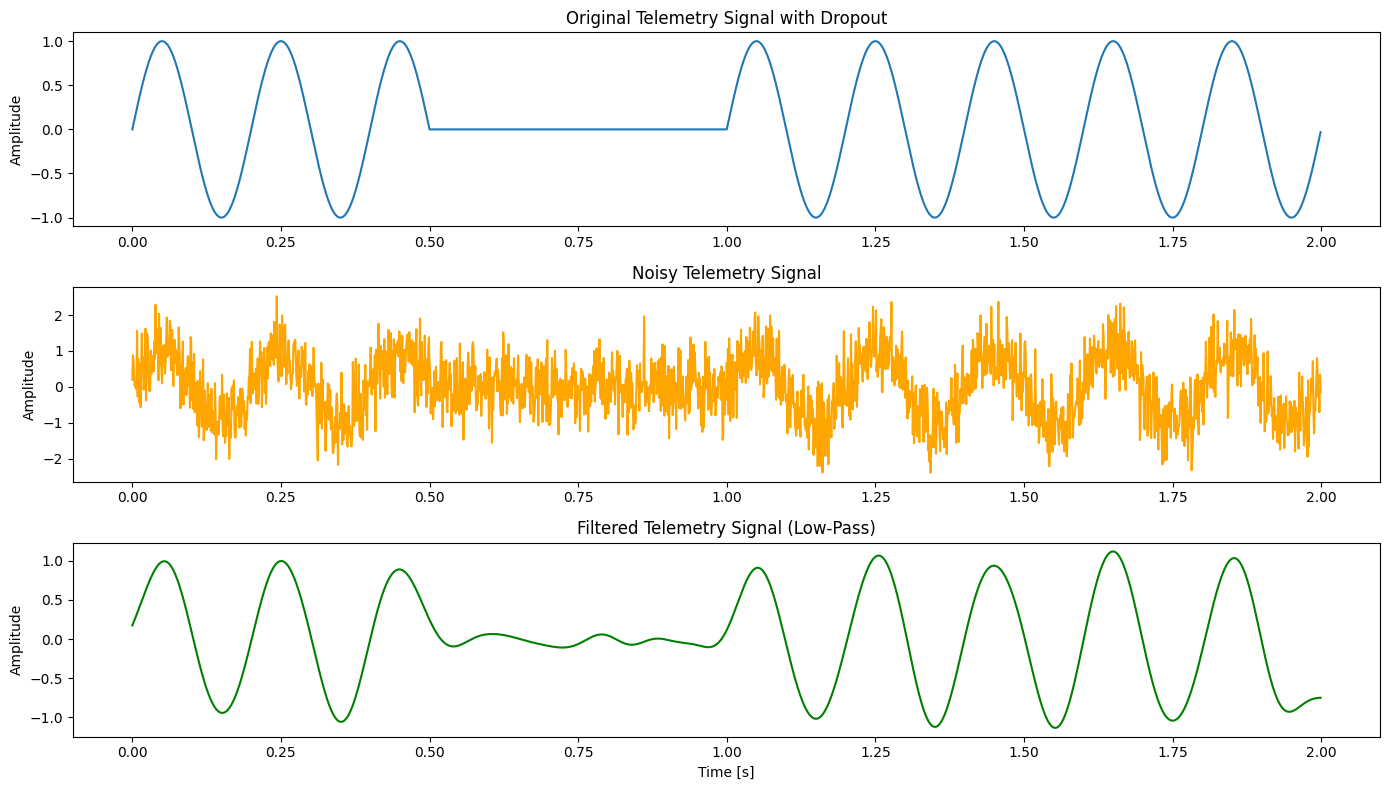

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

# --- 1. Generate telemetry-like signal (sine burst) ---
def generate_telemetry_signal(freq=5, duration=2, sample_rate=1000):
    t = np.linspace(0, duration, int(sample_rate * duration), endpoint=False)
    signal = np.sin(2 * np.pi * freq * t)

    # Create burst effect (simulate transmission drop)
    burst_start, burst_end = int(0.5*sample_rate), int(1.0*sample_rate)
    signal[burst_start:burst_end] = 0  # simulate dropout

    return t, signal

# --- 2. Add Gaussian noise ---
def add_noise(signal, noise_level=0.5):
    noise = np.random.normal(0, noise_level, len(signal))
    noisy_signal = signal + noise
    return noisy_signal, noise

# --- 3. Filter (Low-pass) ---
def lowpass_filter(signal, cutoff=10, sample_rate=1000, order=4):
    nyq = 0.5 * sample_rate
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    filtered = filtfilt(b, a, signal)
    return filtered

# --- 4. Calculate SNR ---
def calculate_snr(clean, noise):
    power_signal = np.mean(clean**2)
    power_noise = np.mean(noise**2)
    snr_db = 10 * np.log10(power_signal / power_noise)
    return snr_db

# --- 5. ALERT system ---
def check_signal_alert(filtered_signal, threshold=0.2):
    if np.max(np.abs(filtered_signal)) < threshold:
        print("⚠️ ALERT: Signal too weak! Possible loss of telemetry.")
    else:
        print("✅ Signal strength acceptable.")

# --- 6. Run all steps ---
t, telemetry = generate_telemetry_signal()
noisy_telemetry, noise = add_noise(telemetry, noise_level=0.6)
filtered_telemetry = lowpass_filter(noisy_telemetry)

snr = calculate_snr(telemetry, noise)
print(f"SNR after filtering: {snr:.2f} dB")

check_signal_alert(filtered_telemetry)

# --- 7. Plot all ---
plt.figure(figsize=(14, 8))

plt.subplot(3,1,1)
plt.title("Original Telemetry Signal with Dropout")
plt.plot(t, telemetry)
plt.ylabel("Amplitude")

plt.subplot(3,1,2)
plt.title("Noisy Telemetry Signal")
plt.plot(t, noisy_telemetry, color='orange')
plt.ylabel("Amplitude")

plt.subplot(3,1,3)
plt.title("Filtered Telemetry Signal (Low-Pass)")
plt.plot(t, filtered_telemetry, color='green')
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()

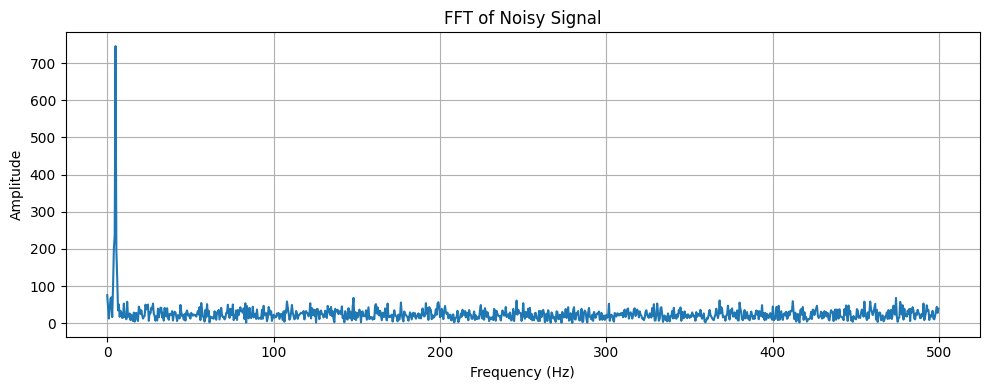

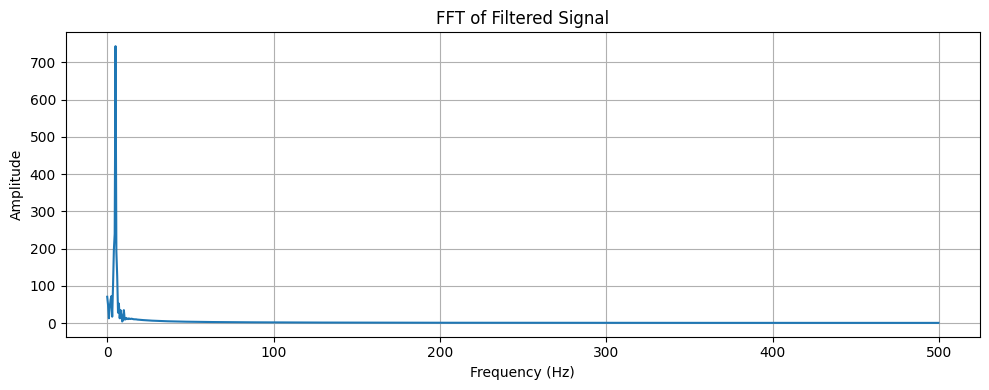

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

# --- Generate signal ---
def generate_telemetry_signal(freq=5, duration=2, sample_rate=1000):
    t = np.linspace(0, duration, int(sample_rate * duration), endpoint=False)
    signal = np.sin(2 * np.pi * freq * t)
    signal[int(0.5*sample_rate):int(1.0*sample_rate)] = 0
    return t, signal

def add_noise(signal, noise_level=0.6):
    noise = np.random.normal(0, noise_level, len(signal))
    return signal + noise, noise

def lowpass_filter(signal, cutoff=10, sample_rate=1000, order=4):
    nyq = 0.5 * sample_rate
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, signal)

# Run steps
t, telemetry = generate_telemetry_signal()
noisy_telemetry, noise = add_noise(telemetry)
filtered_telemetry = lowpass_filter(noisy_telemetry)

# --- FFT Plot Function ---
def plot_fft(signal, sample_rate=1000, title="FFT"):
    n = len(signal)
    freqs = np.fft.fftfreq(n, d=1/sample_rate)
    fft_values = np.abs(np.fft.fft(signal))

    plt.figure(figsize=(10, 4))
    plt.plot(freqs[:n//2], fft_values[:n//2])
    plt.title(title)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# --- Plot FFTs ---
plot_fft(noisy_telemetry, title="FFT of Noisy Signal")
plot_fft(filtered_telemetry, title="FFT of Filtered Signal")

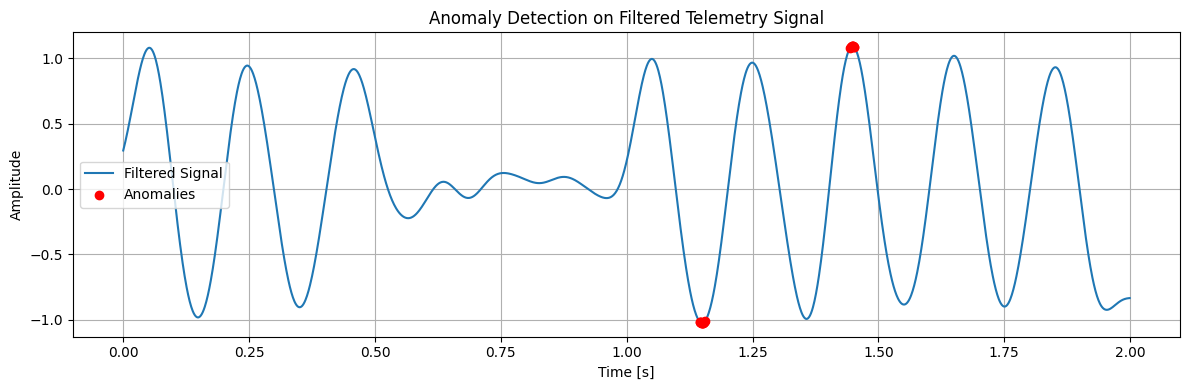

In [ ]:
from sklearn.ensemble import IsolationForest

def detect_anomalies(signal, contamination=0.01):
    reshaped = signal.reshape(-1, 1)
    model = IsolationForest(contamination=contamination, random_state=42)
    labels = model.fit_predict(reshaped)
    return labels

# Detect anomalies
anomaly_labels = detect_anomalies(filtered_telemetry)

# Plot anomalies on signal
plt.figure(figsize=(12, 4))
plt.plot(t, filtered_telemetry, label="Filtered Signal")
plt.scatter(t[anomaly_labels == -1], filtered_telemetry[anomaly_labels == -1], color='red', label='Anomalies', zorder=5)
plt.title("Anomaly Detection on Filtered Telemetry Signal")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# Export filtered telemetry with timestamps and anomaly labels
df = pd.DataFrame({
    'Time': t,
    'FilteredTelemetry': filtered_telemetry,
    'Anomaly': anomaly_labels
})

df.to_csv("cleaned_telemetry_signal.csv", index=False)
print("📁 Exported cleaned signal to 'cleaned_telemetry_signal.csv'")

📁 Exported cleaned signal to 'cleaned_telemetry_signal.csv'


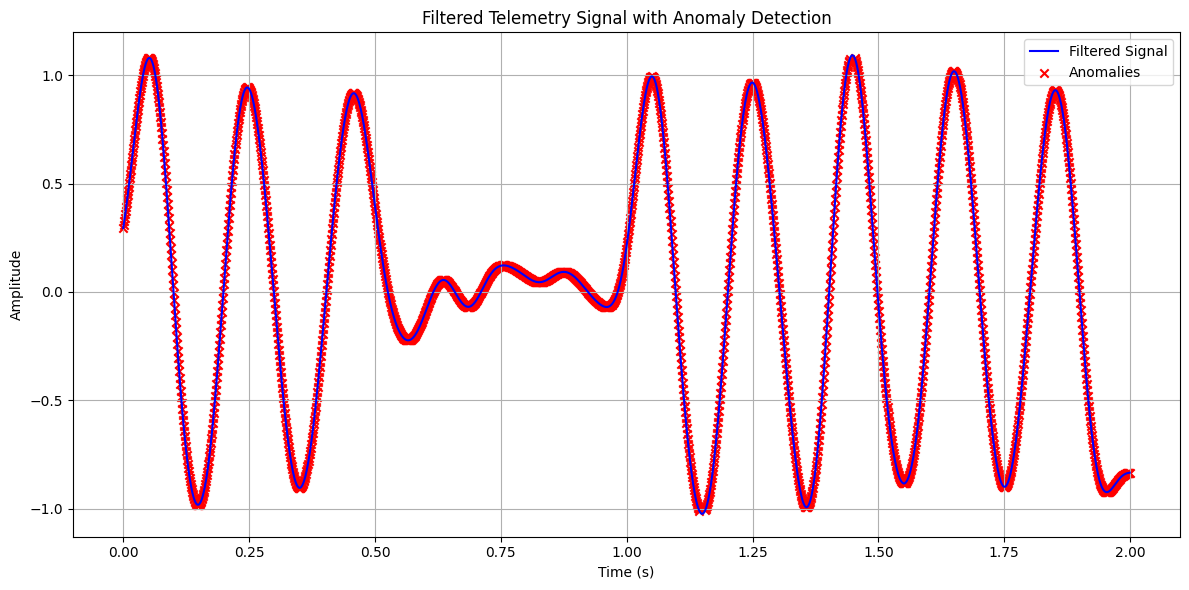

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(t, filtered_telemetry, label="Filtered Signal", color='blue')
plt.scatter(t[anomaly_labels == 1], filtered_telemetry[anomaly_labels == 1],
            color='red', label="Anomalies", marker='x')
plt.title("Filtered Telemetry Signal with Anomaly Detection")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()